# Question 1. Real GDP across US states

# 1.1

In [45]:
%pip install fredapi

Note: you may need to restart the kernel to use updated packages.


In [46]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from fredapi import Fred # Import FRED API

from states import STATES # Import list of states

# FRED API
fred = Fred(api_key="4f86a7b51eb44046f4bc746cb4acc02a")

# Dictionaries
gdp = {}
pop = {}

# Download data
for state in STATES:
    print(f"Downloading {state}...")

    gdp[state] = fred.get_series(f"{state}RGSP")
    pop[state] = fred.get_series(f"{state}POP")

# Convert to DataFrames
df_gdp = pd.DataFrame(gdp)
df_pop = pd.DataFrame(pop)

In [47]:
# Convert index to year
df_gdp.index = pd.to_datetime(df_gdp.index).year 
df_pop.index = pd.to_datetime(df_pop.index).year 

display(df_gdp.head())
display(df_pop.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
1997,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1998,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1999,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8
2000,168695.3,38428.1,224729.3,95509.8,1784320.6,238739.3,233874.2,63388.8,693837.3,417713.5,...,32124.9,251030.2,989904.9,98648.5,24844.6,372914.1,325857.6,63364.6,248572.0,26614.2
2001,168448.3,40014.4,230885.6,95528.7,1784567.7,242650.1,236338.1,65724.8,714638.0,422731.6,...,32396.9,250311.4,1020517.0,100244.3,25681.8,386444.7,317860.6,63599.8,252941.8,28338.1


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
1900,1830.0,NaN,124.0,1314.0,1490.0,543.0,910.0,185.0,530.0,2220.0,...,403.0,2023.0,3055.0,277.0,344.0,1858.0,523.0,959.0,2072.0,93.0
1901,1907.0,NaN,131.0,1341.0,1550.0,581.0,931.0,187.0,544.0,2263.0,...,418.0,2041.0,3132.0,284.0,347.0,1887.0,583.0,972.0,2109.0,100.0
1902,1935.0,NaN,138.0,1360.0,1623.0,621.0,952.0,188.0,565.0,2305.0,...,431.0,2060.0,3210.0,292.0,349.0,1894.0,651.0,1000.0,2141.0,105.0
1903,1957.0,NaN,144.0,1384.0,1702.0,652.0,972.0,190.0,587.0,2346.0,...,437.0,2082.0,3291.0,299.0,350.0,1890.0,719.0,1037.0,2171.0,108.0
1904,1978.0,NaN,151.0,1419.0,1792.0,659.0,987.0,192.0,599.0,2387.0,...,452.0,2086.0,3374.0,308.0,353.0,1889.0,782.0,1064.0,2202.0,111.0


In [48]:
# Keep only common years
common_years = df_gdp.index.intersection(df_pop.index)

# Drop years with missing observations
df_gdp = df_gdp.loc[common_years]
df_pop = df_pop.loc[common_years]

# Drop states with missing observations
df_gdp = df_gdp.dropna(axis=1)
df_pop = df_pop.dropna(axis=1)

# Print summary
print(f"Years left: {len(df_gdp)}")
print(f"States left: {len(df_gdp.columns)}")

Years left: 29
States left: 50


In [49]:
df_gdp_pc = df_gdp / df_pop * 1000

display(df_gdp_pc.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
1997,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1998,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1999,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
2000,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
2001,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668


In [50]:
# First and last year
first = df_gdp_pc.iloc[0]
last = df_gdp_pc.iloc[-1]

print("First year")
print("Highest:", first.max(), "State:", first.idxmax())
print("Lowest:", first.min(), "State:", first.idxmin())
print("Ratio:", first.max() / first.min())
print("Average:", first.mean())

print()

print("Last year")
print("Highest:", last.max(), "State:", last.idxmax())
print("Lowest:", last.min(), "State:", last.idxmin())
print("Ratio:", last.max() / last.min())
print("Average:", last.mean())

First year
Highest: 69748.74289819108 State: DE
Lowest: 32062.68099960517 State: ID
Ratio: 2.1753871081164418
Average: 44592.94585067332

Last year
Highest: 94701.98791376667 State: NY
Lowest: 42434.02523898502 State: MS
Ratio: 2.2317465142751054
Average: 64674.46481951765


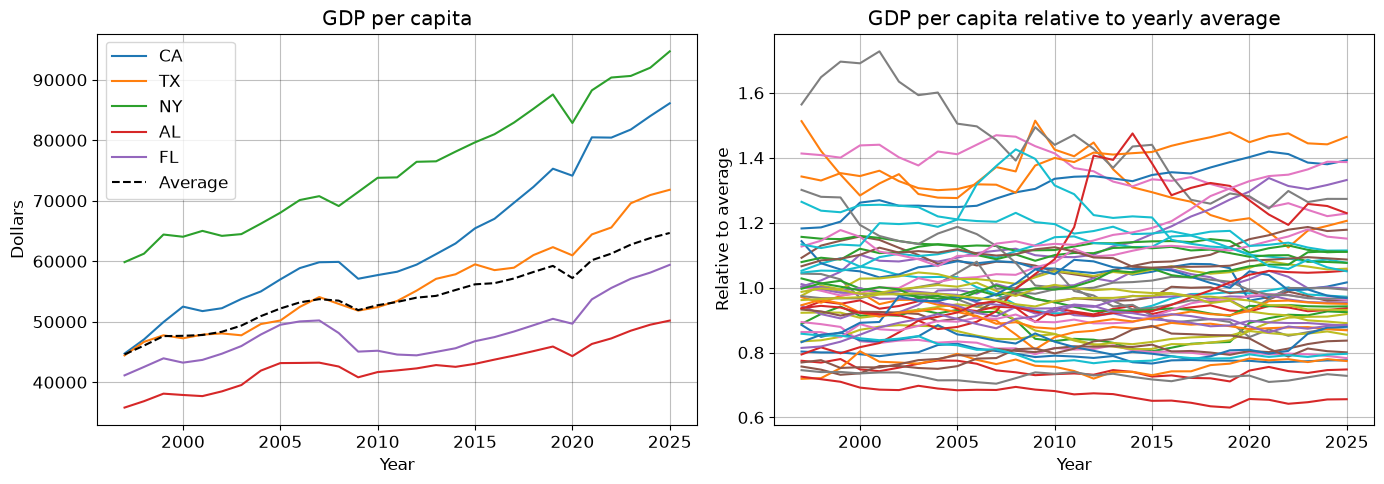

In [51]:
# Average GDP per capita across states
average = df_gdp_pc.mean(axis=1)

# A few states of your choice
states = ["CA", "TX", "NY", "AL", "FL"]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Panel 1
for state in states:
    ax[0].plot(df_gdp_pc.index, df_gdp_pc[state], label=state) # Plot GDP per capita for each state

ax[0].plot(df_gdp_pc.index, average, "k--", label="Average")
ax[0].set_title("GDP per capita")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Dollars")
ax[0].legend()

# Panel 2
relative = df_gdp_pc.divide(average, axis=0)

for state in df_gdp_pc.columns:
    ax[1].plot(relative.index, relative[state])

ax[1].set_title("GDP per capita relative to yearly average")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Relative to average")

plt.tight_layout()
plt.show()

# 1.2

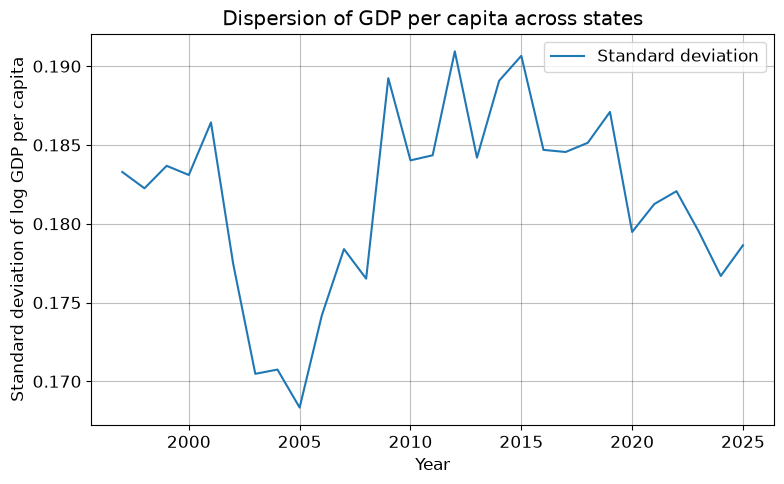

In [52]:
# Log GDP per capita
log_gdp_pc = np.log(df_gdp_pc)

# Standard deviation across states for each year
std = log_gdp_pc.std(axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(std.index, std)
plt.xlabel("Year")
plt.ylabel("Standard deviation of log GDP per capita")
plt.title("Dispersion of GDP per capita across states")
plt.grid(True)
plt.legend(["Standard deviation"])
plt.tight_layout()
plt.show()

In [53]:
# Print summary
print("First year:", std.iloc[0])
print("Last year:", std.iloc[-1])

print("Highest:", std.max())
print("Year:", std.idxmax())

print("Lowest:", std.min())
print("Year:", std.idxmin())

First year: 0.18328585778108922
Last year: 0.17863248031034776
Highest: 0.19094282639042146
Year: 2012
Lowest: 0.16833338925603575
Year: 2005


The dispersion of log GDP per capita across states is fairly stable over time. There is a noticeable decline from about 2001 to 2005, followed by an increase until around 2012. One possible explanation is that the housing boom in the early 2000s benefited some states more than others, while the housing market crash during the Great Recession reduced these differences. However, the figure alone cannot confirm this explanation.

# 1.3

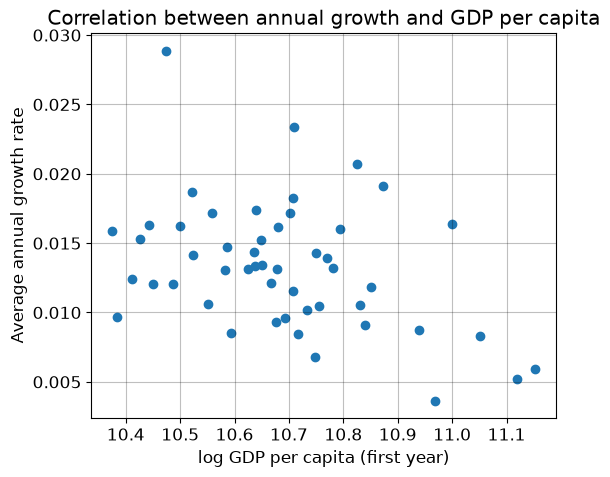

In [54]:
# Average annual growth rate denominator
T = df_gdp_pc.index[-1] - df_gdp_pc.index[0]

# Average annual growth rate
g = (np.log(last) - np.log(first)) / T

# Plot
plt.figure(figsize=(6,5))
plt.scatter(np.log(first), g)

plt.xlabel("log GDP per capita (first year)")
plt.ylabel("Average annual growth rate")
plt.title("Correlation between annual growth and GDP per capita")
plt.show()

a = 0.11808936079725181
b = -0.009802151612523426
Correlation = -0.3886167658049338


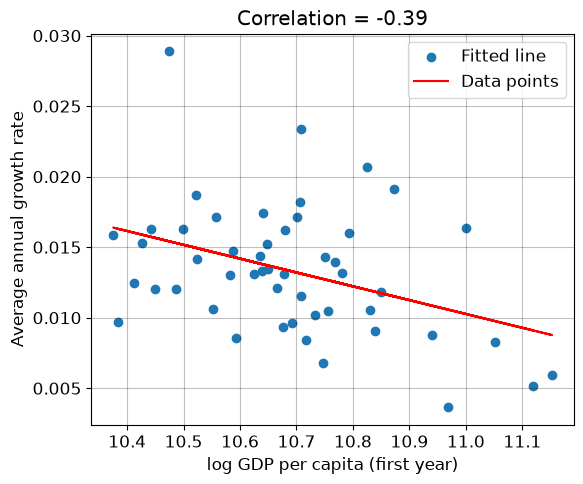

In [55]:
# Fit line: g = a + b*log(first)
b, a = np.polyfit(np.log(first), g, 1)

# Correlation
corr = np.corrcoef(np.log(first), g)[0,1]

# Print results
print("a =", a)
print("b =", b)
print("Correlation =", corr)

# Scatter plot and fitted line
plt.figure(figsize=(6,5))
plt.scatter(np.log(first), g)

# Fitted line
x = np.log(first)
plt.plot(x, a + b*x, color="red")

# Plot
plt.xlabel("log GDP per capita (first year)")
plt.ylabel("Average annual growth rate")
plt.legend(["Fitted line", "Data points"])
plt.title(f"Correlation = {corr:.2f}")
plt.tight_layout()
plt.show()

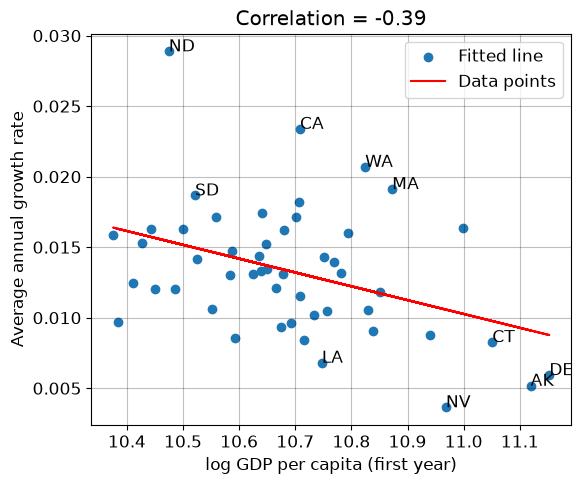

In [56]:
# Five highest and five lowest growth states
highest = g.nlargest(5)
lowest = g.nsmallest(5)

# Scatter plot
plt.figure(figsize=(6,5))
plt.scatter(np.log(first), g)

# Fitted line
x = np.log(first)
plt.plot(x, a + b*x, color="red")

# Add labels
for state in highest.index:
    plt.text(np.log(first[state]), g[state], state)

for state in lowest.index:
    plt.text(np.log(first[state]), g[state], state)

# Plot
plt.xlabel("log GDP per capita (first year)")
plt.ylabel("Average annual growth rate")
plt.legend(["Fitted line", "Data points"])
plt.title(f"Correlation = {corr:.2f}")
plt.tight_layout()
plt.show()

In [57]:
# Speed of convergence
lam = -np.log(1 + b * T) / T

# Half-life
h = np.log(2) / lam

print("Lambda:", lam)
print("Half-life:", h)

Lambda: 0.011458550416960303
Half-life: 60.491698804587685


The fitted line has a negative slope, showing that states with lower initial GDP per capita generally had higher growth rates than richer states, indicating convergence. The points are fairly scattered around the line, but with a correlation of -0.39 there is a moderate negative relationship, so the fit is reasonable but not very strong.

# 1.4

In [58]:
from states import REGION

# GDP per capita relative to the US average
relative = df_gdp_pc.div(df_gdp_pc.mean(axis=1), axis=0)

# Average for each region
region_avg = pd.DataFrame()

for region in set(REGION.values()):
    states = [state for state in REGION if REGION[state] == region] # Get states in the region
    region_avg[region] = relative[states].mean(axis=1)

# Display the first few rows of the region averages
display(region_avg.head())

# Print the number of states in each region
for region in set(REGION.values()):
    states = [state for state in REGION if REGION[state] == region] # Get states in the region
    print(region, len(states))

,Northeast,Midwest,West,South
1997,1.087340,0.968332,1.028682,0.951318
1998,1.087564,0.968472,1.020313,0.957887
1999,1.091557,0.962879,1.021444,0.958916
2000,1.110827,0.976595,1.014661,0.943301
2001,1.119563,0.969318,1.008820,0.948591


Northeast 9
Midwest 12
West 13
South 16


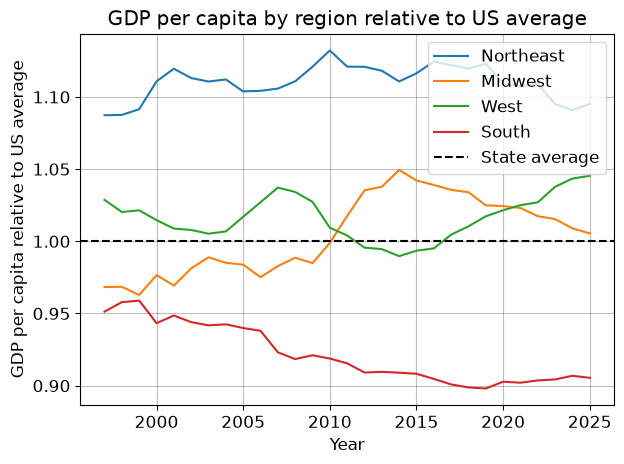

In [59]:
# Plot GDP per capita by region relative to US average
plt.plot(region_avg)

# Add horizontal line at y=1 to indicate the state average
plt.axhline(y=1, color="black", linestyle="--", label="State average")

# Plot
plt.xlabel("Year")
plt.ylabel("GDP per capita relative to US average")
plt.legend(region_avg.columns.tolist() + ["State average"])
plt.title("GDP per capita by region relative to US average")
plt.tight_layout()
plt.show()

In [60]:
# First year
print("First year")
print(region_avg.iloc[0])

print() # Add a blank line for better readability

# Last year
print("Last year")
print(region_avg.iloc[-1])

print() # Add a blank line for better readability

# Change
print("Change")
print(region_avg.iloc[-1] - region_avg.iloc[0])

First year
Northeast    1.087340
Midwest      0.968332
West         1.028682
South        0.951318
Name: 1997, dtype: float64

Last year
Northeast    1.095232
Midwest      1.005527
West         1.045378
South        0.905418
Name: 2025, dtype: float64

Change
Northeast    0.007892
Midwest      0.037194
West         0.016696
South       -0.045900
dtype: float64


The South moves the most over the sample period. Its relative GDP per capita decreases, meaning that the South falls further below the national average.

# Question 2: The Solow model with a time-varying savings rate


In [61]:
%matplotlib inline
import numpy as np
from scipy import optimize
from SolowModel import *

model = SolowModelClass() 
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


In [62]:
k_star, y_star, c_star = model.steady_state()      # analytical, at s = par.s_bar
k_star_numeric = model.solve_steady_state()         # numerical (root-finder)

print(f'analytical steady state: k* = {k_star:.4f}, y* = {y_star:.4f}, c* = {c_star:.4f}')
print(f'numerical (root-finder): k* = {k_star_numeric:.4f}')
assert abs(k_star - k_star_numeric) < 1e-8
print('the root-finder confirms the closed-form k*')

analytical steady state: k* = 0.7607, y* = 0.9129, c* = 0.6847
numerical (root-finder): k* = 0.7607
the root-finder confirms the closed-form k*


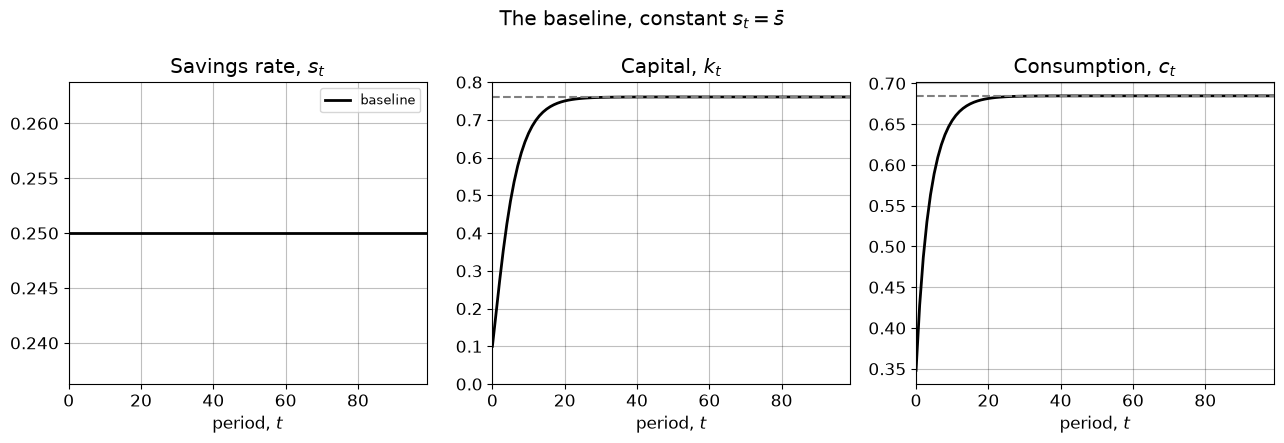

In [63]:
sim_base = copy_sim(model.simulate(model.par.s_bar)) # the baseline: constant s_t = s_bar

# Plot the baseline simulation
fig = plot_three_panels(sim_base, k_star=k_star, c_star=c_star, title='The baseline, constant $s_t=\\bar{s}$')
plt.show()

In [64]:
# Print the last values of consumption and capital
print(f'c_0     = {sim_base.c[0]:.4f}') # Initial consumption
print(f'c_(T-1) = {sim_base.c[-1]:.4f}') # Final consumption
print(f'k_(T-1) = {sim_base.k[-1]:.4f}   (k* = {k_star:.4f})') # Final capital

c_0     = 0.3481
c_(T-1) = 0.6847
k_(T-1) = 0.7607   (k* = 0.7607)


In [65]:
# test 1: an economy starting in the steady state must stay there
sim_ss = model.simulate(model.par.s_bar, k0=k_star)
assert np.allclose(sim_ss.k, k_star), 'an economy starting in k* should stay in k*'

# test 2: with s=0 nothing is invested, so capital decays as k_t = (1-delta)**t * k0
sim_zero = model.simulate(0.0)
t = np.arange(model.par.T)
assert np.allclose(sim_zero.k, (1-model.par.delta)**t*model.par.k0), 'with s=0 capital should decay geometrically'

print('both tests passed')

both tests passed


**The two tests.** Test 1 checks that an economy starting excatly in the steady state, k0=k*, stays there forever. Test 2 checks that with a savings rate of zero nothing is invested, so capital simply decays as kt = (1-delta)^t*k0. Both tests pass, which is a basic sanity check that the law of motion is implemented correctly in simulate

## 2.2 Four combinations

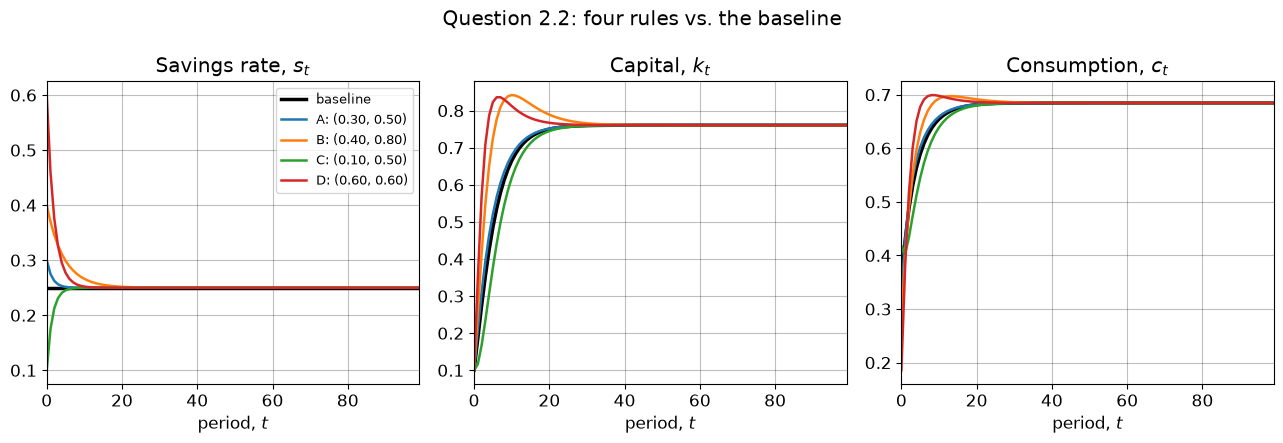

In [66]:
# Simulate four different rules for s_t, starting from the same initial capital k0=k_star
combos = {
    'A: (0.30, 0.50)': (0.30, 0.50),
    'B: (0.40, 0.80)': (0.40, 0.80),
    'C: (0.10, 0.50)': (0.10, 0.50),
    'D: (0.60, 0.60)': (0.60, 0.60),
}
names = list(combos.keys())
sims_q2 = [simulate_rule(model, s0, phi) for s0, phi in combos.values()] # s_t = s_bar+(s0-s_bar)*phi**t

fig = plot_three_panels(sim_base, sims_q2, names, title='Question 2.2: four rules vs. the baseline')
plt.show()

In [67]:
# Print the last values of consumption and capital for each simulation
table_k = k_last_table(sim_base, sims_q2, names)
print(table_k.round(6).to_string())

                  k_(T-1)
rule                     
baseline         0.760726
A: (0.30, 0.50)  0.760726
B: (0.40, 0.80)  0.760726
C: (0.10, 0.50)  0.760726
D: (0.60, 0.60)  0.760726


**Is k_(T-1) the same for all five rules?** Yes, k_(T-1) is numerically identical for the baseline and all four combinations. Since phi is always less than 1, phi^t goes to zero as t grows, so s_t goes to s_bar under every rule no matter what s0 and phi are. All five economies therefore converge to exactly the same steady state, k* = (s_bar/delta)^(1/(1-alpha)), only the transition path towards it differs.

s0 sets how far the savings rate starts from s_bar in period 0: s0 above s_bar (A, B, D) means investing more than the baseline at first, s0 belows s_bar (C) means investing less. Phi controls how fast s_t returns to s_bar: phi close to 1 (B: 0.80) means a slow, long-lived deviation from the baseline, while phi further from 1 (A, C: 0.50) means the savings rate is back near s_bar within a few periods

## 2.3 Welfare of the four combinations

In [68]:
table_W = welfare_table(model, sim_base, sims_q2, names) # uses model.welfare(c)
print(table_W.round(5).to_string())

# Identify the combinations that beat the baseline in terms of welfare
winners = [name for name, row in table_W.iterrows() if name != 'baseline' and row['W - W_baseline'] > 0]
print('')
print(f'combinations beating the baseline: {winners}')

                       W  W - W_baseline
rule                                    
baseline        -3.99439         0.00000
A: (0.30, 0.50) -3.98571         0.00868
B: (0.40, 0.80) -4.09141        -0.09702
C: (0.10, 0.50) -4.14602        -0.15163
D: (0.60, 0.60) -4.34065        -0.34627

combinations beating the baseline: ['A: (0.30, 0.50)']


**Could you have seen that from the Question 2.2 figure alone?** Not reliably. W is a discounted, nonlinear sum over the whole consumption path, so it aggregates the entire figure into one number in a way you cannot read off bye eye. A rule that cuts consumption early can still win on welfare if it raises capital, and therefore consumption, enough in later periods to outweigh the early loss once discounted. The figure shows the shapes of the three paths; it does not show how the discounting and the log curvature weigh early against late consumption. 

## 2.4 The optimal two-parameter rule 

best grid point: s0 = 0.3100, phi = 0.2300, W = -3.984306


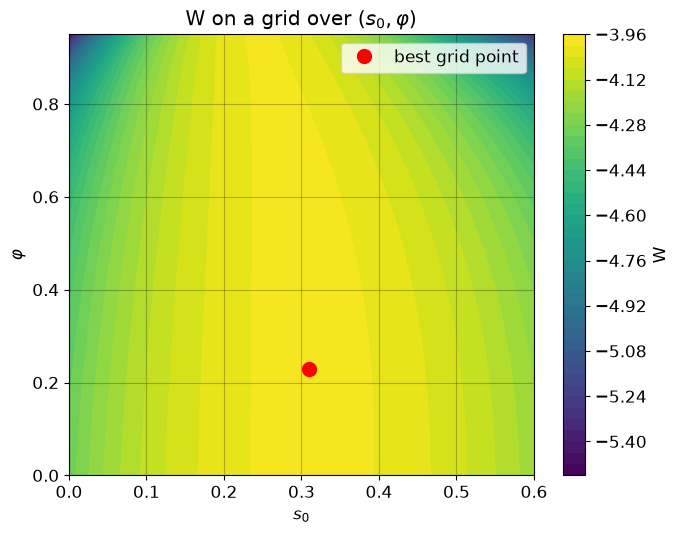

In [69]:
# Grid search over s0 and phi to find the combination that maximizes welfare
s0_grid = np.linspace(0.0, 0.60, 61)
phi_grid = np.linspace(0.0, 0.95, 96)

# Run the grid search
W_grid, s0_grid_best, phi_grid_best, W_grid_best = grid_search(model, s0_grid, phi_grid)

print(f'best grid point: s0 = {s0_grid_best:.4f}, phi = {phi_grid_best:.4f}, W = {W_grid_best:.6f}')

# Plot the welfare grid
fig = plot_welfare_grid(s0_grid, phi_grid, W_grid, s0_grid_best, phi_grid_best)
plt.show()

In [70]:
# Define the negative welfare function for optimization
def neg_W_2p(params):
    s0, phi = params
    return -model.evaluate(s0, phi)

# Use a numerical optimizer to find the optimal s0 and phi that maximize welfare
res4 = optimize.minimize(neg_W_2p, x0=[s0_grid_best, phi_grid_best], 
                          bounds=((0.0, 1.0), (0.0, 0.999)))
s0_opt, phi_opt = res4.x
W_opt = -res4.fun

# Print the results of the numerical optimization
print(f'numerical optimum: s0 = {s0_opt:.4f}, phi = {phi_opt:.4f}, W = {W_opt:.6f}')
print(f'improvement over the grid: {W_opt - W_grid_best:.6f}')

numerical optimum: s0 = 0.3115, phi = 0.2208, W = -3.984300
improvement over the grid: 0.000006


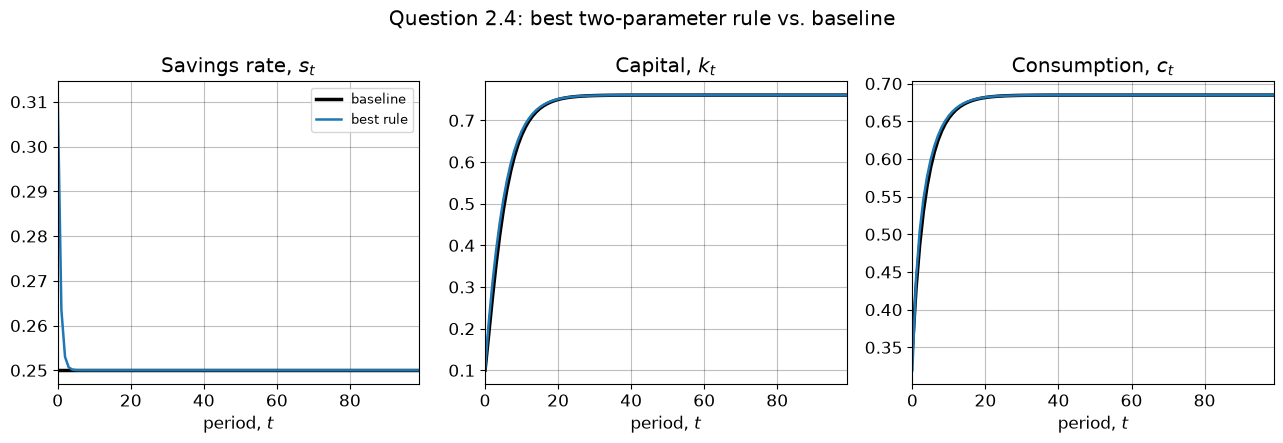

c_0 under the best rule = 0.3196   (baseline c_0 = 0.3481)
first period with c_t above the baseline: t = 1


In [71]:
sim_best_q4 = simulate_rule(model, s0_opt, phi_opt) # s_target defaults to par.s_bar

# Plot the best two-parameter rule against the baseline
fig = plot_three_panels(sim_base, [sim_best_q4], ['best rule'],
                         title='Question 2.4: best two-parameter rule vs. baseline')
plt.show()

# Print the last values of consumption and capital for the best rule
c0_best = sim_best_q4.c[0]
above = sim_best_q4.c > sim_base.c
t_above = int(np.argmax(above)) if above.any() else None

print(f'c_0 under the best rule = {c0_best:.4f}   (baseline c_0 = {sim_base.c[0]:.4f})')
print(f'first period with c_t above the baseline: t = {t_above}')

## 2.5 The optimal three-parameter rule 

In [72]:
# model.evaluate() always targets par.s_bar, so with a free s_infinity we
# simulate through simulate_rule(..., s_target=...) instead

def neg_W_3p(params):
    s0, phi, s_inf = params
    sim = simulate_rule(model, s0, phi, s_target=s_inf)
    return -model.welfare(sim.c)

# Use a numerical optimizer to find the optimal s0, phi, and s_infinity that maximize welfare
res5 = optimize.minimize(neg_W_3p, x0=[s0_opt, phi_opt, model.par.s_bar], 
                          bounds=((0.0, 1.0), (0.0, 0.999), (0.0, 1.0)))
s0_opt5, phi_opt5, sinf_opt5 = res5.x
W_opt5 = -res5.fun

# Print the results of the three-parameter optimization
print(f'optimum: s0 = {s0_opt5:.4f}, phi = {phi_opt5:.4f}, s_infinity = {sinf_opt5:.4f}')
print(f'W = {W_opt5:.6f}   (Question 4: W = {W_opt:.6f}, improvement = {W_opt5 - W_opt:.6f})')

optimum: s0 = 0.3139, phi = 0.6708, s_infinity = 0.1989
W = -3.966965   (Question 4: W = -3.984300, improvement = 0.017335)


In [73]:
# Simulate the best three-parameter rule and compute the steady state implied by s_infinity
sim_best_q5 = simulate_rule(model, s0_opt5, phi_opt5, s_target=sinf_opt5)
k_star_sinf = model.steady_state(sinf_opt5)[0] # steady state implied by s_infinity instead of s_bar

# Print the last values of consumption and capital for the best three-parameter rule
print(f'k_(T-1) under the best 3-parameter rule = {sim_best_q5.k[-1]:.4f}')
print(f'k* from Question 1 (built on s_bar={model.par.s_bar})     = {k_star:.4f}')
print(f'k* implied by the found s_infinity={sinf_opt5:.4f}      = {k_star_sinf:.4f}')

k_(T-1) under the best 3-parameter rule = 0.5400
k* from Question 1 (built on s_bar=0.25)     = 0.7607
k* implied by the found s_infinity=0.1989      = 0.5400


**Are k_(T-1) and k* the same, and should they be?** 
In general no. k_(T-1) converges to the steady state implied by whichever s_infinity the optimizer settles on in the long run, not to k* from Question 1, which is built on s_bar. Since it is optimal, given log utility and the discount factor, to save persistently more or less than s_bar forever rather than returning to it, the two steady states only coincide in the special case where the optimizer happens to pick s_infinity equal to s_bar, which is not what a genuine three-parameter optimum is expected to do, and indeed is not what happens here.

## 2.6 An alternative functional form for s_t

**Proposed alternative: hyperbolic (power-law) decay.** Instead of the
geometric decay used in equation (6), let the savings rate return to its
long-run level as

s_t = s_infinity + (s0-s_infinity)*(1+t)^- p

At t=0 this gives s_0, exactly the same boundary condition as (6), and as
t grows, s_t goes to infinity, so the economy still settles at a steady state. Unlike geometric decay, a power law has a "fat tail": it falls quickly at first but then decays much more slowly once t is large, so it lets the savings rate linger away from infinity for longer before finally settling down, instead of converging at a constant proportional rate every period. It is implemented as s_path_alt and simulate_rule_alt in SolowModel.

In [74]:
# Define the negative welfare function for the power rule optimization
def neg_W_power(params):
    s0, p, s_inf = params
    sim = simulate_rule_alt(model, s0, p, s_inf)
    return -model.welfare(sim.c)

# Use a numerical optimizer to find the optimal s0, p, and s_infinity that maximize welfare
res6 = optimize.minimize(neg_W_power, x0=[s0_opt5, 1.0, sinf_opt5],
                          bounds=((0.0, 1.0), (0.01, 50.0), (0.0, 1.0)))
s0_opt6, p_opt6, sinf_opt6 = res6.x
W_opt6 = -res6.fun

print(f'optimum: s0 = {s0_opt6:.4f}, p = {p_opt6:.4f}, s_infinity = {sinf_opt6:.4f}')
print(f'W = {W_opt6:.6f}')

optimum: s0 = 0.3169, p = 0.5515, s_infinity = 0.1622
W = -3.967428


In [75]:
# Compare the three rules in terms of welfare
table_q6 = pd.DataFrame([
    {'rule': 'Q4: 2-parameter geometric (s_target = s_bar)', '#params': 2, 'W': W_opt},
    {'rule': 'Q5: 3-parameter geometric (free s_infinity)',  '#params': 3, 'W': W_opt5},
    {'rule': 'Q6: 3-parameter power-law (free s_infinity)',  '#params': 3, 'W': W_opt6},
]).set_index('rule')

print(table_q6.round(6).to_string())

# Compare the power-law rule to the best geometric rule
if W_opt6 > W_opt5 + 1e-6:
    print(f'\n-> the power-law rule beats Question 5 by {W_opt6 - W_opt5:.6f}.')
elif W_opt6 < W_opt5 - 1e-6:
    print(f'\n-> the power-law rule does NOT beat Question 5 (W is {W_opt5 - W_opt6:.6f} lower).')
else:
    print('\n-> essentially a tie between the two 3-parameter families.')

                                              #params         W
rule                                                           
Q4: 2-parameter geometric (s_target = s_bar)        2 -3.984300
Q5: 3-parameter geometric (free s_infinity)         3 -3.966965
Q6: 3-parameter power-law (free s_infinity)         3 -3.967428

-> the power-law rule does NOT beat Question 5 (W is 0.000463 lower).


Both Question 5 and Question 6 have three free parameters, so it is not
surprising if they land close to each other: with the same number of degrees
of freedom, both families are flexible enough to trace out a very similar
optimal consumption path, even though the two decay shapes look different on
paper. Whether the power-law rule actually beats Question 5 (rather than only
tying with it) is reported by the comparison above, which is computed
directly from the optimized W's rather than assumed.

# 3. A portfolio with a risky and a safe asset

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# plot settings
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black', 'grid.alpha': 0.25, 'grid.linestyle': '-'})
plt.rcParams.update({'font.size': 12})
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from PortfolioModel import PortfolioModelClass

model = PortfolioModelClass()  # default parameters, as in the assignment
par = model.par
print(model)

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


## 3.1

In [77]:
R = model.draw_returns() # draw returns
print(f'R has shape {R.shape}')

R has shape (50000, 40)


In [78]:
logR = np.log(R)

print(f'mean of log R_t:  {logR.mean():.4f}   (mu = {par.mu:.4f})\n'
      f'std of log R_t:   {logR.std():.4f}   (sigma = {par.sigma:.4f})\n\n'
      f'mean of R_t:                 {R.mean():.4f}\n'
      f'exp(mu + 0.5*sigma**2):      {np.exp(par.mu+0.5*par.sigma**2):.4f}')

mean of log R_t:  0.0500   (mu = 0.0500)
std of log R_t:   0.2000   (sigma = 0.2000)

mean of R_t:                 1.0725
exp(mu + 0.5*sigma**2):      1.0725


Both checks match closely: the mean and standard deviation of
$\log R_t$ are close to $\mu$ and $\sigma$, and the mean of $R_t$ is close
to $\exp(\mu+\tfrac12\sigma^2)$, as expected for a lognormal variable.

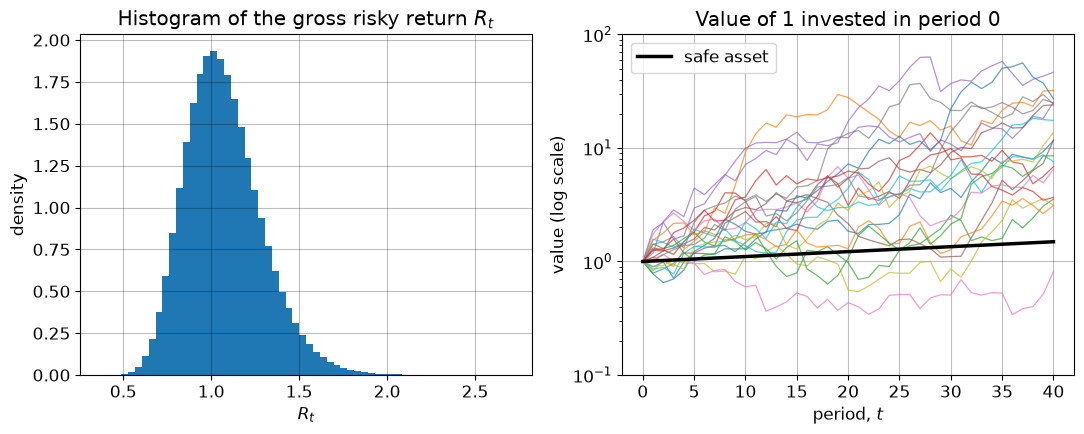

In [79]:
Rf = np.exp(par.r)

# value of 1 invested in period 0 and never traded: V_0=1, V_{t+1}=V_t*R_t
V_risky = np.empty((par.N, par.T + 1))
V_risky[:, 0] = 1.0
V_safe = np.empty(par.T + 1)
V_safe[0] = 1.0
for t in range(par.T):
    V_risky[:, t + 1] = V_risky[:, t] * R[:, t]
    V_safe[t + 1] = V_safe[t] * Rf

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# i. histogram of the gross risky return. R has shape (N,T); reshape(-1)
#    turns it into one long 1D array of all the draws, for one histogram.
axes[0].hist(R.reshape(-1), bins=60, density=True, color=colors[0])
axes[0].set_title('Histogram of the gross risky return $R_t$')
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('density')

# ii. value of 1 invested in period 0, log scale
# y-limits fixed to 0.1-100, so the log axis gets clean labeled ticks
t_grid = np.arange(par.T + 1)
for i in range(20):
    axes[1].plot(t_grid, V_risky[i, :], lw=0.9, color=colors[i % len(colors)], alpha=0.7)
axes[1].plot(t_grid, V_safe, lw=2.5, color='black', label='safe asset')
axes[1].set_yscale('log')
axes[1].set_ylim(0.1, 100)
axes[1].set_title('Value of 1 invested in period 0')
axes[1].set_xlabel('period, $t$')
axes[1].set_ylabel('value (log scale)')
axes[1].legend(loc='upper left')

fig.tight_layout()
fig.savefig('q1_returns.png')
plt.show()

Panel i) is bell-shaped and centered a little above 1, since $R_t$ is
built from a normal shock $\varepsilon_t$: it is the histogram of
$\exp(\mu+\sigma\varepsilon_t)$, and $\exp$ turns the symmetric normal
shape into a slightly right-skewed one, with a longer tail on the high side
than the low side.

In panel ii), each coloured line is one of the 20 risky-asset portfolios,
and the thick black line is the safe asset, which grows at a constant rate
(a straight line on the log scale). The risky paths trend up on average,
since the risky asset has a higher expected return, but they are spread
out, and some end up below the safe asset even after 40 periods.

## 3.2

In [80]:
# Delta and tau are set on each model, not passed to .simulate(), so we
# need one model per rule. Both use the same R, so they are comparable.
model_d0 = PortfolioModelClass(Delta=0.0, tau=0.0)
sim_d0 = model_d0.simulate(R=R)
summary_d0 = model_d0.summary()

model_d1 = PortfolioModelClass(Delta=1.0, tau=0.0)
sim_d1 = model_d1.simulate(R=R)
summary_d1 = model_d1.summary()

table_extremes = pd.DataFrame(
    [summary_d0, summary_d1],
    index=['delta=0 (trade every period)', 'delta=1 (never trade)'],
)
table_extremes

,n_trades,avg_dist,mean_WT,median_WT,p10_WT,E[u(WT)]
delta=0 (trade every period),39.0,0.039395,5.043602,4.081492,1.793667,-0.067829
delta=1 (never trade),0.0,0.191138,8.975620,4.447803,1.485479,-0.076690


With τ=0, trading is free. Δ=0 rebalances almost every period (39/40) and stays close to target. Δ=1 never trades, so the risky share drifts, increasing both distance from target and spread in terminal wealth. The drift raises mean terminal wealth (5.04 → 8.98) since the risky asset earns more, but lowers the 10th percentile and expected utility, since CRRA (γ=3) penalizes the extra downside risk.

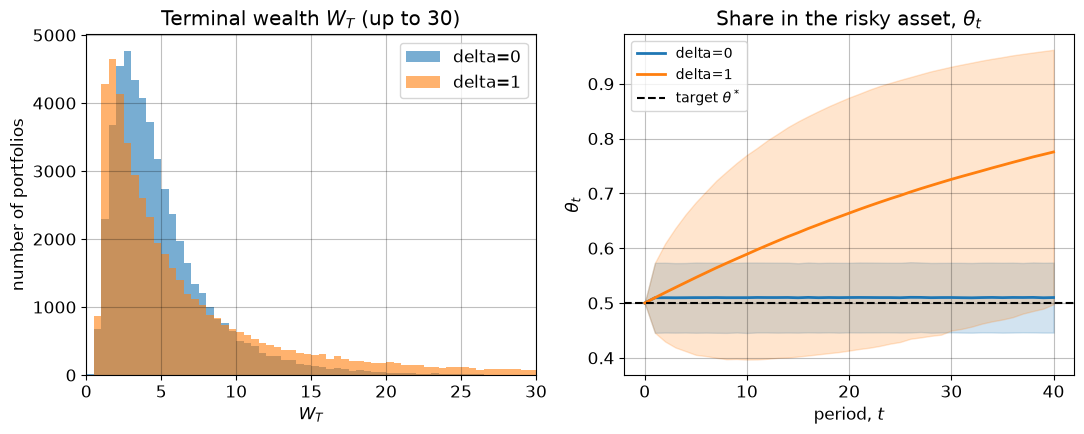

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# i. histogram of terminal wealth for both rules, up to W_T=30
# (a few portfolios go higher; the text below reports how many)
wealth_bins = np.linspace(0, 30, 61)
axes[0].hist(sim_d0.W[-1, :], bins=wealth_bins, alpha=0.6, color=colors[0], label='delta=0')
axes[0].hist(sim_d1.W[-1, :], bins=wealth_bins, alpha=0.6, color=colors[1], label='delta=1')
axes[0].set_xlim(0, 30)
axes[0].set_title('Terminal wealth $W_T$ (up to 30)')
axes[0].set_xlabel('$W_T$')
axes[0].set_ylabel('number of portfolios')
axes[0].legend()

# ii. mean theta_t over time, with a 10th-90th percentile band across portfolios
t_grid = np.arange(par.T + 1)
for sim, label, c in [(sim_d0, 'delta=0', colors[0]), (sim_d1, 'delta=1', colors[1])]:
    theta_mean = sim.theta.mean(axis=1)
    theta_lo = np.percentile(sim.theta, 10, axis=1)
    theta_hi = np.percentile(sim.theta, 90, axis=1)
    axes[1].fill_between(t_grid, theta_lo, theta_hi, color=c, alpha=0.2)
    axes[1].plot(t_grid, theta_mean, color=c, lw=2, label=label)
axes[1].axhline(par.theta_star, ls='--', lw=1.5, color='black', label=r'target $\theta^*$')
axes[1].set_title(r'Share in the risky asset, $\theta_t$')
axes[1].set_xlabel('period, $t$')
axes[1].set_ylabel(r'$\theta_t$')
axes[1].legend(loc='upper left', fontsize=10)

fig.tight_layout()
fig.savefig('q2_extremes.png')
plt.show()

In [82]:
# theta_t for delta=1 at three points in time
theta1_start = sim_d1.theta[0, :]
theta1_mid = sim_d1.theta[par.T // 4, :]
theta1_end = sim_d1.theta[-1, :]

print(f'delta=1, theta_t: mean (std) at t=0:              {theta1_start.mean():.4f} ({theta1_start.std():.4f})\n'
      f'delta=1, theta_t: mean (std) at t={par.T // 4}:               {theta1_mid.mean():.4f} ({theta1_mid.std():.4f})\n'
      f'delta=1, theta_t: mean (std) at t={par.T} (last period): {theta1_end.mean():.4f} ({theta1_end.std():.4f})')

delta=1, theta_t: mean (std) at t=0:              0.5000 (0.0000)
delta=1, theta_t: mean (std) at t=10:               0.5890 (0.1416)
delta=1, theta_t: mean (std) at t=40 (last period): 0.7756 (0.1870)


The mean θ_t rises from 0.50 to about 0.78, since the risky asset earns more and nothing pulls it back. The spread grows to about 0.19 as portfolios diverge. Δ=0's θ_t isn't exactly 0.50 either (~0.51, measured pre-trade), but that drift is tiny by comparison.

## 3.3

In [83]:
deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]

# one model per delta, all using the same R
rows3 = []
for d in deltas:
    m = PortfolioModelClass(Delta=d, tau=0.01)
    m.simulate(R=R)
    rows3.append(m.summary())

table3 = pd.DataFrame(rows3, index=deltas)
table3.index.name = 'delta'
table3

,n_trades,avg_dist,mean_WT,median_WT,p10_WT,E[u(WT)]
delta,,,,,,
0.000,39.00000,0.039395,4.962427,4.018396,1.768274,-0.069934
0.025,24.52346,0.039974,4.974622,4.018379,1.769181,-0.069745
0.050,14.33342,0.042948,5.015482,4.035755,1.767369,-0.069505
0.075,8.79048,0.047986,5.073901,4.047645,1.765500,-0.069347
0.100,5.86028,0.054052,5.145886,4.060641,1.759388,-0.069460
0.150,3.15190,0.068029,5.328542,4.104170,1.735272,-0.069950
0.200,1.95026,0.083468,5.559645,4.186286,1.679246,-0.070944
0.300,0.90548,0.117972,6.195680,4.341368,1.536125,-0.073406
1.000,0.00000,0.191138,8.975620,4.447803,1.485479,-0.076690


Panel i) has both the number of trades and the average distance to target,
on the same axis (the distance is turned into percentage points, i.e.
multiplied by 100, so both lines are on a similar scale). Panel ii) has
expected utility.

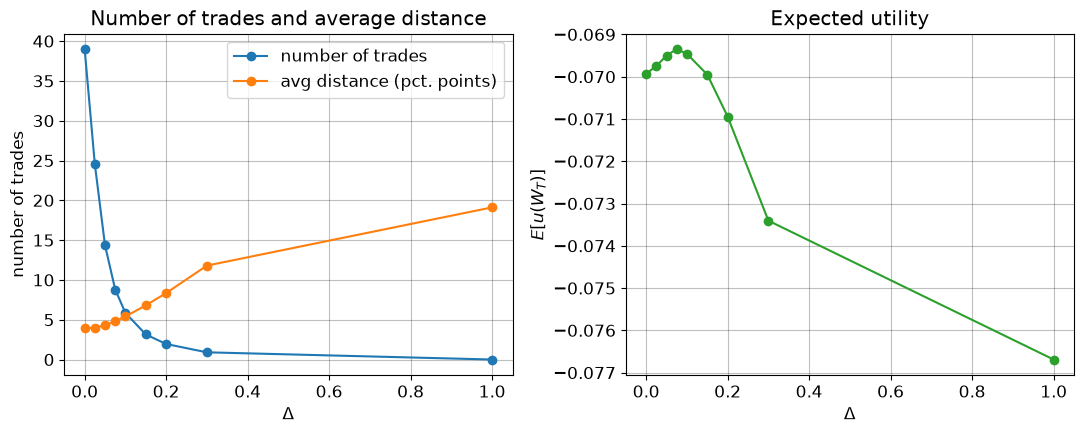

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# i. number of trades and average distance (in percentage points), same axis
axes[0].plot(table3.index, table3['n_trades'], marker='o', color=colors[0], label='number of trades')
axes[0].plot(table3.index, table3['avg_dist'] * 100, marker='o', color=colors[1], label='avg distance (pct. points)')
axes[0].set_title('Number of trades and average distance')
axes[0].set_xlabel(r'$\Delta$')
axes[0].set_ylabel('number of trades')
axes[0].legend()

# ii. expected utility
axes[1].plot(table3.index, table3['E[u(WT)]'], marker='o', color=colors[2])
axes[1].set_title('Expected utility')
axes[1].set_xlabel(r'$\Delta$')
axes[1].set_ylabel(r'$E[u(W_T)]$')

fig.tight_layout()
fig.savefig('q3_grid.png')
plt.show()

In [85]:
# the delta with the highest expected utility
best_i = np.argmax(table3['E[u(WT)]'].values)
best_delta = table3.index[best_i]
best_row = table3.loc[best_delta]

print(f"best delta (by expected utility): {best_delta}\n"
      f"E[u(WT)] at best delta: {best_row['E[u(WT)]']:.6f}\n"
      f"E[u(WT)] at delta=0:    {table3.loc[0.0, 'E[u(WT)]']:.6f}   (beaten by {best_row['E[u(WT)]']-table3.loc[0.0,'E[u(WT)]']:.6f})\n"
      f"E[u(WT)] at delta=1:    {table3.loc[1.0, 'E[u(WT)]']:.6f}   (beaten by {best_row['E[u(WT)]']-table3.loc[1.0,'E[u(WT)]']:.6f})")

best delta (by expected utility): 0.075
E[u(WT)] at best delta: -0.069347
E[u(WT)] at delta=0:    -0.069934   (beaten by 0.000588)
E[u(WT)] at delta=1:    -0.076690   (beaten by 0.007343)


The numbers below are all from the table in section 1 above.

From Δ=0 to the best Δ: trades drop sharply (39 → under 9), while distance to target barely rises (0.04 → 0.05) and wealth (mean, median, 10th percentile) barely changes. Expected utility improves only slightly. So a small band mainly saves on trading costs.

Ranking by mean W_T instead disagrees: it keeps rising toward Δ=1, since a wider band lets the risky share drift up toward its higher return, but that ignores the extra downside risk, which is exactly what expected utility penalizes.